In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


# STEP 1 - IMPORT LIBRARIES

In [2]:
import os
import gc
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, spearmanr

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# STEP 2 - SET PATHS AND PARAMETERS

In [3]:
BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

FEATURES_PATH = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
CLASSES_PATH  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
EDGES_PATH    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

TX_COL = "txId"
TIME_COL = "time_step"
RAW_CLASS_COL = "class"
CLASS_LABEL_COL = "class_label"

PAGERANK_ALPHA = 0.85
BETWEENNESS_K_PER_STEP = 1000
ZSCORE_THRESHOLD = 2.0
EXTREME_ASYM_THRESHOLD = 0.7

print("FEATURES_PATH:", FEATURES_PATH)
print("CLASSES_PATH :", CLASSES_PATH)
print("EDGES_PATH   :", EDGES_PATH)

# RNG seed — dùng nhất quán cho tất cả stochastic operations
SEED = 42
BC_SEEDS = [42, 7, 123]   # 3 seeds cho betweenness stability check
np.random.seed(SEED)

FEATURES_PATH: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
CLASSES_PATH : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
EDGES_PATH   : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


# STEP 3 - LOAD DATA

In [4]:
features_df = pd.read_csv(FEATURES_PATH, header=None)
classes_df = pd.read_csv(CLASSES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

print("features_df shape:", features_df.shape)
print("classes_df  shape:", classes_df.shape)
print("edges_df    shape:", edges_df.shape)

display(features_df.head())
display(classes_df.head())
display(edges_df.head())

features_df shape: (203769, 167)
classes_df  shape: (203769, 2)
edges_df    shape: (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


# SANITY ASSERTIONS 

In [5]:
# SANITY ASSERTIONS 
assert features_df.shape[0] == 203769, \
    f"Expected 203769 nodes, got {features_df.shape[0]}"
assert edges_df.shape[0] == 234355, \
    f"Expected 234355 edges, got {edges_df.shape[0]}"
assert set(classes_df["class"].astype(str).unique()).issubset({"1", "2", "unknown"}), \
    f"Unexpected class labels: {classes_df['class'].astype(str).unique()}"
assert classes_df["txId"].nunique() == len(classes_df), \
    "Duplicate txIds found in classes_df"
print("✓ All sanity assertions passed.")

✓ All sanity assertions passed.


# STEP 4 - PREPARE NODE AND LABEL TABLES

In [6]:
n_cols = features_df.shape[1]
col_names = [TX_COL, TIME_COL] + [f"feature_{i}" for i in range(2, n_cols)]
features_df.columns = col_names

node_df = features_df[[TX_COL, TIME_COL]].copy()

classes_df[RAW_CLASS_COL] = classes_df[RAW_CLASS_COL].astype(str)

# Elliptic mapping đúng:
# 1 = illicit, 2 = licit, unknown = unknown
class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

classes_df[CLASS_LABEL_COL] = classes_df[RAW_CLASS_COL].map(class_map).str.lower()

base_df = node_df.merge(
    classes_df[[TX_COL, RAW_CLASS_COL, CLASS_LABEL_COL]],
    on=TX_COL,
    how="left"
)

print(base_df.shape)
print(base_df[CLASS_LABEL_COL].value_counts(dropna=False))
display(base_df.head())

(203769, 4)
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


# STEP 5 - BUILD THE FULL DIRECTED GRAPH

In [7]:
G = nx.DiGraph()

G.add_nodes_from(base_df[TX_COL].tolist())

source_col = edges_df.columns[0]
target_col = edges_df.columns[1]

edge_tuples = list(edges_df[[source_col, target_col]].itertuples(index=False, name=None))
G.add_edges_from(edge_tuples)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is DAG?:", nx.is_directed_acyclic_graph(G))
print("Weakly connected components:", nx.number_weakly_connected_components(G))

Number of nodes: 203769
Number of edges: 234355
Is DAG?: True
Weakly connected components: 49


# STEP 6 - PARTITION THE GRAPH BY TIME STEP

In [8]:
time_steps = sorted(base_df[TIME_COL].dropna().unique().tolist())
print("Number of time steps:", len(time_steps))
print("First 10 time steps:", time_steps[:10])

nodes_by_timestep = {
    t: base_df.loc[base_df[TIME_COL] == t, TX_COL].tolist()
    for t in time_steps
}

timestep_stats = []

for t in time_steps:
    nodes_t = nodes_by_timestep[t]
    G_t = G.subgraph(nodes_t).copy()

    n_nodes = G_t.number_of_nodes()
    n_edges = G_t.number_of_edges()
    density = nx.density(G_t) if n_nodes > 1 else 0.0
    n_wcc = nx.number_weakly_connected_components(G_t) if n_nodes > 0 else 0

    timestep_stats.append({
        TIME_COL: t,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "density": density,
        "n_weak_components": n_wcc
    })

timestep_stats_df = pd.DataFrame(timestep_stats)
display(timestep_stats_df.head())
display(timestep_stats_df.describe())

Number of time steps: 49
First 10 time steps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


,time_step,n_nodes,n_edges,density,n_weak_components
0,1,7880,9164,0.000148,1
1,2,4544,5241,0.000254,1
2,3,6621,8316,0.000190,1
3,4,5693,8180,0.000252,1
4,5,6803,8623,0.000186,1


,time_step,n_nodes,n_edges,density,n_weak_components
count,49.00000,49.000000,49.000000,49.000000,49.0
mean,25.00000,4158.551020,4782.755102,0.000318,1.0
std,14.28869,1592.470592,2081.940236,0.000146,0.0
min,1.00000,1089.000000,1168.000000,0.000148,1.0
25%,13.00000,2891.000000,3094.000000,0.000224,1.0
50%,25.00000,4291.000000,4656.000000,0.000261,1.0
75%,37.00000,5121.000000,5950.000000,0.000376,1.0
max,49.00000,7880.000000,9164.000000,0.000986,1.0


# **STEP 7 - COMPUTE PER-TIMESTEP NODE METRICS**

tính metrics cho từng node trong từng timestep

In [9]:
def safe_asymmetry(in_deg, out_deg):
    total = in_deg + out_deg
    if total == 0:
        return 0.0
    return (in_deg - out_deg) / total

ps3_node_metric_frames = []

for t in time_steps:
    nodes_t = nodes_by_timestep[t]
    G_t = G.subgraph(nodes_t).copy()

    if G_t.number_of_nodes() == 0:
        continue

    # degree metrics
    in_deg_dict = dict(G_t.in_degree())
    out_deg_dict = dict(G_t.out_degree())

# approximate betweenness within timestep — 3-seed stability
    k_t = min(BETWEENNESS_K_PER_STEP, G_t.number_of_nodes())
    BC_SEEDS = [42, 7, 123]
    bet_runs = []
    for _seed in BC_SEEDS:
        _b = nx.betweenness_centrality(G_t, k=k_t, normalized=True, seed=_seed)
        bet_runs.append(_b)

    # median betweenness across 3 seeds (node-level)
    all_nodes_t = list(G_t.nodes())
    bet_dict = {
        n: float(np.median([run.get(n, 0.0) for run in bet_runs]))
        for n in all_nodes_t
    }
    # stability range (dùng để report sau)
    bet_range_dict = {
        n: float(max(run.get(n, 0.0) for run in bet_runs) -
                 min(run.get(n, 0.0) for run in bet_runs))
        for n in all_nodes_t
    }

    # pagerank
    pr_dict = nx.pagerank(G_t, alpha=PAGERANK_ALPHA)

    # clustering coefficient (undirected view cho ổn định)
    clust_dict = nx.clustering(G_t.to_undirected())

    # weakly connected component size
    comp_size_dict = {}
    for comp in nx.weakly_connected_components(G_t):
        size = len(comp)
        for n in comp:
            comp_size_dict[n] = size

    records_t = []
    for n in G_t.nodes():
        in_d = in_deg_dict.get(n, 0)
        out_d = out_deg_dict.get(n, 0)
        total_d = in_d + out_d
        asym = safe_asymmetry(in_d, out_d)

        records_t.append({
            TX_COL: n,
            TIME_COL: t,
            "in_degree_t": in_d,
            "out_degree_t": out_d,
            "total_degree_t": total_d,
            "asymmetry_t": asym,
            "abs_asymmetry_t": abs(asym),
            "betweenness_t": bet_dict.get(n, 0.0),
            "bet_stability_range_t": bet_range_dict.get(n, 0.0),
            "pagerank_t": pr_dict.get(n, 0.0),
            "clustering_t": clust_dict.get(n, 0.0),
            "wcc_size_t": comp_size_dict.get(n, 1)
        })

    ps3_node_metric_frames.append(pd.DataFrame(records_t))
    gc.collect()

ps3_node_df = pd.concat(ps3_node_metric_frames, ignore_index=True)

print("ps3_node_df shape:", ps3_node_df.shape)
display(ps3_node_df.head())

ps3_node_df shape: (203769, 12)


,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,bet_stability_range_t,pagerank_t,clustering_t,wcc_size_t
0,4947969,1,1,1,2,0.0,0.0,0.000006,0.000019,0.000228,0.0,7880
1,4947974,1,1,1,2,0.0,0.0,0.000006,0.000019,0.000233,0.0,7880
2,4947979,1,1,1,2,0.0,0.0,0.000016,0.000022,0.000247,0.0,7880
3,82706446,1,1,0,1,1.0,1.0,0.000000,0.000000,0.000123,0.0,7880
4,4947982,1,1,1,2,0.0,0.0,0.000016,0.000027,0.000247,0.0,7880


# STEP 8 - COMPUTE WITHIN-TIMESTEP Z-SCORES AND OUTLIER FLAGS

chuẩn hóa (z-score) trong từng timestep + flag outlier node

In [10]:
def safe_group_zscore(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

z_metrics = {
    "z_betweenness_t": "betweenness_t",
    "z_degree_t": "total_degree_t",
    "z_asymmetry_t": "asymmetry_t",      #đã bỏ abs asymetry
    "z_pagerank_t": "pagerank_t"
}

for z_col, raw_col in z_metrics.items():
    ps3_node_df[z_col] = (
        ps3_node_df
        .groupby(TIME_COL)[raw_col]
        .transform(safe_group_zscore)
    )

ps3_node_df["flag_z_betweenness_t"] = (ps3_node_df["z_betweenness_t"].abs() > ZSCORE_THRESHOLD).astype(int)
ps3_node_df["flag_z_degree_t"]      = (ps3_node_df["z_degree_t"].abs() > ZSCORE_THRESHOLD).astype(int)
ps3_node_df["flag_z_asymmetry_t"]   = (ps3_node_df["z_asymmetry_t"].abs() > ZSCORE_THRESHOLD).astype(int)
ps3_node_df["flag_z_pagerank_t"]    = (ps3_node_df["z_pagerank_t"].abs() > ZSCORE_THRESHOLD).astype(int)

flag_cols = [
    "flag_z_betweenness_t",
    "flag_z_degree_t",
    "flag_z_asymmetry_t",
    "flag_z_pagerank_t"
]

ps3_node_df["outlier_flag_count_t"] = ps3_node_df[flag_cols].sum(axis=1)
ps3_node_df["within_timestep_outlier"] = (ps3_node_df["outlier_flag_count_t"] > 0).astype(int)

display(ps3_node_df.head())

,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,bet_stability_range_t,pagerank_t,clustering_t,wcc_size_t,z_betweenness_t,z_degree_t,z_asymmetry_t,z_pagerank_t,flag_z_betweenness_t,flag_z_degree_t,flag_z_asymmetry_t,flag_z_pagerank_t,outlier_flag_count_t,within_timestep_outlier
0,4947969,1,1,1,2,0.0,0.0,0.000006,0.000019,0.000228,0.0,7880,0.030500,-0.065959,0.122723,0.438545,0,0,0,0,0,0
1,4947974,1,1,1,2,0.0,0.0,0.000006,0.000019,0.000233,0.0,7880,0.026215,-0.065959,0.122723,0.459605,0,0,0,0,0,0
2,4947979,1,1,1,2,0.0,0.0,0.000016,0.000022,0.000247,0.0,7880,0.386529,-0.065959,0.122723,0.520730,0,0,0,0,0,0
3,82706446,1,1,0,1,1.0,1.0,0.000000,0.000000,0.000123,0.0,7880,-0.194834,-0.268355,1.713188,-0.018527,0,0,0,0,0,0
4,4947982,1,1,1,2,0.0,0.0,0.000016,0.000027,0.000247,0.0,7880,0.373009,-0.065959,0.122723,0.520730,0,0,0,0,0,0


# STEP 9 - BUILD TIMESTEP-LEVEL AGGREGATE STATISTICS

gom metrics → thành đặc trưng của từng timestep

In [11]:
def safe_skew(series):
    if series.nunique() <= 1:
        return 0.0
    return series.skew()

def safe_kurtosis(series):
    if series.nunique() <= 1:
        return 0.0
    return series.kurt()

timestep_agg_df = (
    ps3_node_df
    .groupby(TIME_COL)
    .agg(
        mean_betweenness_t = ("betweenness_t", "mean"),
        median_betweenness_t = ("betweenness_t", "median"),
        std_betweenness_t = ("betweenness_t", "std"),

        mean_total_degree_t = ("total_degree_t", "mean"),
        median_total_degree_t = ("total_degree_t", "median"),
        std_total_degree_t = ("total_degree_t", "std"),

        mean_asymmetry_t = ("asymmetry_t", "mean"),
        mean_pagerank_t = ("pagerank_t", "mean"),

        frac_extreme_asymmetry_t = ("asymmetry_t", lambda s: (s.abs() > EXTREME_ASYM_THRESHOLD).mean()),
        outlier_node_count_t = ("within_timestep_outlier", "sum"),
        outlier_node_fraction_t = ("within_timestep_outlier", "mean"),

        degree_skewness_t = ("total_degree_t", safe_skew),
        degree_kurtosis_t = ("total_degree_t", safe_kurtosis)
    )
    .reset_index()
)

timestep_agg_df = timestep_agg_df.merge(timestep_stats_df, on=TIME_COL, how="left")

display(timestep_agg_df.head())

,time_step,mean_betweenness_t,median_betweenness_t,std_betweenness_t,mean_total_degree_t,median_total_degree_t,std_total_degree_t,mean_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_count_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,n_nodes,n_edges,density,n_weak_components
0,1,0.000005,0.000000,0.000028,2.325888,2.0,4.941119,-0.077162,0.000127,0.375000,291,0.036929,37.105762,1766.369856,7880,9164,0.000148,1
1,2,0.000041,0.000000,0.000136,2.306778,2.0,2.543409,-0.082841,0.000220,0.457746,392,0.086268,10.550242,186.680447,4544,5241,0.000254,1
2,3,0.001224,0.000002,0.002569,2.512007,2.0,2.449190,-0.064495,0.000151,0.311131,1105,0.166893,6.319671,53.593381,6621,8316,0.000190,1
3,4,0.000273,0.000000,0.000711,2.873705,2.0,4.971956,-0.093536,0.000176,0.399614,549,0.096434,23.568147,790.146299,5693,8180,0.000252,1
4,5,0.000007,0.000000,0.000021,2.535058,2.0,4.351614,-0.114226,0.000147,0.415552,566,0.083199,26.806668,1109.805428,6803,8623,0.000186,1


In [12]:
# STEP 9 - EXPORT TIMESTEP AGGREGATE STATISTICS

OUTPUT_CSV = "/kaggle/working/ps3_step9_timestep_aggregate.csv"

timestep_agg_df.to_csv(OUTPUT_CSV, index=False)

print("Saved CSV to:", OUTPUT_CSV)
print("Shape:", timestep_agg_df.shape)

display(timestep_agg_df.head())

Saved CSV to: /kaggle/working/ps3_step9_timestep_aggregate.csv
Shape: (49, 18)


,time_step,mean_betweenness_t,median_betweenness_t,std_betweenness_t,mean_total_degree_t,median_total_degree_t,std_total_degree_t,mean_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_count_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,n_nodes,n_edges,density,n_weak_components
0,1,0.000005,0.000000,0.000028,2.325888,2.0,4.941119,-0.077162,0.000127,0.375000,291,0.036929,37.105762,1766.369856,7880,9164,0.000148,1
1,2,0.000041,0.000000,0.000136,2.306778,2.0,2.543409,-0.082841,0.000220,0.457746,392,0.086268,10.550242,186.680447,4544,5241,0.000254,1
2,3,0.001224,0.000002,0.002569,2.512007,2.0,2.449190,-0.064495,0.000151,0.311131,1105,0.166893,6.319671,53.593381,6621,8316,0.000190,1
3,4,0.000273,0.000000,0.000711,2.873705,2.0,4.971956,-0.093536,0.000176,0.399614,549,0.096434,23.568147,790.146299,5693,8180,0.000252,1
4,5,0.000007,0.000000,0.000021,2.535058,2.0,4.351614,-0.114226,0.000147,0.415552,566,0.083199,26.806668,1109.805428,6803,8623,0.000186,1


# STEP 10 - DETECT STRUCTURALLY ANOMALOUS TIME STEPS

- z-score từng metric
- lấy max(|z|)
- nếu > 2 → anomaly time step

In [13]:
# với mỗi time step, mô tả “hình dạng” của graph bằng 10 chỉ số
agg_metric_cols = [
    "mean_betweenness_t",
    "mean_total_degree_t",
    "mean_asymmetry_t",
    "mean_pagerank_t",
    "frac_extreme_asymmetry_t",      # tỷ lệ node extreme asymmetry
    "outlier_node_fraction_t",       # tỷ lệ outlier
    "degree_skewness_t",
    "degree_kurtosis_t",
    "density",
    "n_weak_components"
]

# z = (giá trị của timestep đó - trung bình của 49 timesteps) / độ lệch chuẩn của 49 timesteps
for col in agg_metric_cols:
    zcol = f"z_{col}"
    timestep_agg_df[zcol] = safe_group_zscore(timestep_agg_df[col])

# Gom tất cả độ lệch thành 1 anomaly score
z_agg_cols = [f"z_{c}" for c in agg_metric_cols]
# Giả sử time step 22 có: z_mean_betweenness = 0.3 z_mean_degree = 0.5 z_kurtosis = 5.0 => timestep_anomaly_score = 5.0 (max)
timestep_agg_df["timestep_anomaly_score"] = timestep_agg_df[z_agg_cols].abs().max(axis=1)

# Time step được coi là bất thường nếu có ít nhất một chỉ số cấu trúc lệch hơn 2 độ lệch chuẩn so với mặt bằng chung.
timestep_agg_df["timestep_anomaly_flag"] = (timestep_agg_df["timestep_anomaly_score"] > ZSCORE_THRESHOLD).astype(int)

display(timestep_agg_df[[TIME_COL, "timestep_anomaly_score", "timestep_anomaly_flag"] + agg_metric_cols].head())
print("Anomalous timesteps:", timestep_agg_df["timestep_anomaly_flag"].sum())

,time_step,timestep_anomaly_score,timestep_anomaly_flag,mean_betweenness_t,mean_total_degree_t,mean_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,density,n_weak_components
0,1,2.501871,1,0.000005,2.325888,-0.077162,0.000127,0.375000,0.036929,37.105762,1766.369856,0.000148,1
1,2,0.920351,0,0.000041,2.306778,-0.082841,0.000220,0.457746,0.086268,10.550242,186.680447,0.000254,1
2,3,3.675613,1,0.001224,2.512007,-0.064495,0.000151,0.311131,0.166893,6.319671,53.593381,0.000190,1
3,4,4.001569,1,0.000273,2.873705,-0.093536,0.000176,0.399614,0.096434,23.568147,790.146299,0.000252,1
4,5,1.800973,0,0.000007,2.535058,-0.114226,0.000147,0.415552,0.083199,26.806668,1109.805428,0.000186,1


Anomalous timesteps: 9


In [14]:
# STEP 10 - EXPORT FULL ANOMALY DATASET

OUTPUT_FULL = "/kaggle/working/ps3_step10_timestep_anomaly_full.csv"

timestep_agg_df.to_csv(OUTPUT_FULL, index=False)

print("Saved FULL file to:", OUTPUT_FULL)
print("Shape:", timestep_agg_df.shape)

Saved FULL file to: /kaggle/working/ps3_step10_timestep_anomaly_full.csv
Shape: (49, 30)


# **STEP 10B - NULL MODEL CALIBRATION FOR TIMESTEP ANOMALY DETECTOR**

In [ ]:
# STEP 10B - NULL MODEL CALIBRATION FOR TIMESTEP ANOMALY DETECTOR

import numpy as np

np.random.seed(SEED)
N_SIM = 1000
N_TIMESTEPS = 49
N_METRICS = len(agg_metric_cols)  # số metrics bạn đang dùng trong Step 10

null_flag_counts = []

for _ in range(N_SIM):
    z_matrix = np.random.standard_normal((N_TIMESTEPS, N_METRICS))
    max_abs_z = np.abs(z_matrix).max(axis=1)
    flag_count = (max_abs_z > ZSCORE_THRESHOLD).sum()
    null_flag_counts.append(flag_count)

null_counts = np.array(null_flag_counts)
observed_count = int(timestep_agg_df["timestep_anomaly_flag"].sum())

p95 = np.percentile(null_counts, 95)
p50 = np.percentile(null_counts, 50)
pct_rank = (null_counts < observed_count).mean() * 100

print("=== NULL MODEL CALIBRATION RESULTS ===")
print(f"Number of metrics tested   : {N_METRICS}")
print(f"Observed flagged timesteps : {observed_count}")
print(f"Null mean                  : {null_counts.mean():.1f}")
print(f"Null 50th percentile       : {p50:.1f}")
print(f"Null 95th percentile       : {p95:.1f}")
print(f"Observed percentile in null: {pct_rank:.1f}%")
print()

if observed_count > p95:
    print("✓ PASS — retain timestep anomaly section in thesis")
else:
    print("✗ FAIL — reframe timestep anomaly section in thesis")
    print("  → per-timestep NODE-level 3x enrichment is NOT affected")

# STEP 10C - PLOT NULL DISTRIBUTION

In [ ]:
# STEP 10C - PLOT NULL DISTRIBUTION

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(null_counts, bins=range(0, 35), 
        alpha=0.7, color="steelblue", 
        label="Null distribution (1000 simulations)")

ax.axvline(observed_count, color="crimson", linewidth=2,
           label=f"Observed = {observed_count}")
ax.axvline(p95, color="orange", linewidth=2, linestyle="--",
           label=f"95th percentile = {p95:.1f}")

ax.set_xlabel("Number of flagged timesteps")
ax.set_ylabel("Frequency")
ax.set_title("Null model calibration\nHow many timesteps would be flagged by chance?")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Z=2.0 là ko đủ (kqua 10B)

# Step 10D — Bonferroni-corrected Z threshold 

In [15]:
from scipy import stats

# Tìm ngưỡng Z để P(max|z_1,...,z_10| > threshold) = 0.05
# P(tất cả 10 metrics đều < threshold) = 0.95
# P(1 metric < threshold) = 0.95^(1/10)

alpha = 0.05
n_metrics = 10
per_metric_alpha = 1 - (1 - alpha) ** (1/n_metrics)
bonferroni_z = stats.norm.ppf(1 - per_metric_alpha/2)

print(f"Šidák-corrected Z threshold: {bonferroni_z:.4f}")
# Kết quả là 2.7996

Šidák-corrected Z threshold: 2.7996


# chạy lại Null model vs ngưỡng Z mới

In [16]:
ZSCORE_THRESHOLD_CORRECTED = bonferroni_z  
null_flag_counts_corrected = []
for _ in range(1000):
    z_matrix = np.random.standard_normal((49, 10))
    max_abs_z = np.abs(z_matrix).max(axis=1)
    flag_count = (max_abs_z > ZSCORE_THRESHOLD_CORRECTED).sum()
    null_flag_counts_corrected.append(flag_count)

null_corrected = np.array(null_flag_counts_corrected)

# Chạy lại trên data thực với ngưỡng mới
timestep_agg_df["timestep_anomaly_flag_corrected"] = (
    timestep_agg_df["timestep_anomaly_score"] > ZSCORE_THRESHOLD_CORRECTED
).astype(int)

observed_corrected = timestep_agg_df["timestep_anomaly_flag_corrected"].sum()
p95_corrected = np.percentile(null_corrected, 95)

print(f"New threshold Z = {ZSCORE_THRESHOLD_CORRECTED:.4f}")
print(f"Observed flagged: {observed_corrected}")
print(f"Null 95th pct: {p95_corrected:.1f}")
print(f"Null mean: {null_corrected.mean():.1f}")

if observed_corrected > p95_corrected:
    print("✓ PASS")
else:
    print("✗ FAIL")

New threshold Z = 2.7996
Observed flagged: 5
Null 95th pct: 5.0
Null mean: 2.5
✗ FAIL


In [17]:
# Áp dụng ngưỡng Šidák vào timestep_agg_df chính thức
timestep_agg_df["timestep_anomaly_flag"] = (
    timestep_agg_df["timestep_anomaly_score"] > ZSCORE_THRESHOLD_CORRECTED
).astype(int)

print(f"\n=== FINAL ANOMALY FLAGS (Šidák threshold = {ZSCORE_THRESHOLD_CORRECTED:.4f}) ===")
print(f"Flagged timesteps : {timestep_agg_df['timestep_anomaly_flag'].sum()}")
print(f"(Previously with z=2.0: was 9, expected ~18 by chance)")
print(f"Null 95th pct under corrected threshold: {np.percentile(null_flag_counts_corrected, 95):.1f}")
print(f"Observed: {observed_corrected}")

if observed_corrected > np.percentile(null_flag_counts_corrected, 95):
    print("✓ Timestep anomaly detector PASSES with Šidák correction")
else:
    print("✗ Timestep anomaly detector FAILS — reframe section in thesis:")
    print("  → 'No statistically meaningful anomalous timesteps detected'")
    print("  → Per-timestep NODE-level 3× enrichment is unaffected by this conclusion")


=== FINAL ANOMALY FLAGS (Šidák threshold = 2.7996) ===
Flagged timesteps : 5
(Previously with z=2.0: was 9, expected ~18 by chance)
Null 95th pct under corrected threshold: 5.0
Observed: 5
✗ Timestep anomaly detector FAILS — reframe section in thesis:
  → 'No statistically meaningful anomalous timesteps detected'
  → Per-timestep NODE-level 3× enrichment is unaffected by this conclusion


# 10E FDR

In [18]:
# STEP 10E - FDR CORRECTION (Benjamini-Hochberg)

from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

z_agg_cols = [f"z_{c}" for c in agg_metric_cols]

timestep_pval_rows = []

for idx, row in timestep_agg_df.iterrows():
    pvals = []
    for zcol in z_agg_cols:
        z_val = row[zcol]
        pval = 2 * (1 - norm.cdf(abs(z_val)))
        pvals.append(pval)

    reject, pvals_corrected, _, _ = multipletests(
        pvals, alpha=0.05, method="fdr_bh"
    )

    timestep_pval_rows.append({
        TIME_COL: row[TIME_COL],
        "any_significant_fdr": int(any(reject)),
        "n_significant_metrics": int(sum(reject)),
        "min_pval_corrected": float(min(pvals_corrected))
    })

pval_df = pd.DataFrame(timestep_pval_rows)

# Null model cho FDR
null_fdr = []
np.random.seed(SEED)
for _ in range(1000):
    z_matrix = np.random.standard_normal((49, 10))
    flag_count = 0
    for t in range(49):
        pvals_sim = [2*(1 - norm.cdf(abs(z))) for z in z_matrix[t]]
        reject_sim, _, _, _ = multipletests(pvals_sim, alpha=0.05, method="fdr_bh")
        if any(reject_sim):
            flag_count += 1
    null_fdr.append(flag_count)

null_fdr = np.array(null_fdr)
observed_fdr = int(pval_df["any_significant_fdr"].sum())
p95_fdr = np.percentile(null_fdr, 95)

print("=== FDR CORRECTION RESULTS ===")
print(f"Observed flagged timesteps : {observed_fdr}")
print(f"Null mean                  : {null_fdr.mean():.1f}")
print(f"Null 95th percentile       : {p95_fdr:.1f}")
print(f"Observed percentile in null: {(null_fdr < observed_fdr).mean()*100:.1f}%")

if observed_fdr > p95_fdr:
    print("✓ PASS — FDR-corrected timestep anomaly is meaningful")
else:
    print("✗ FAIL — reframe timestep anomaly section")

print("\nFlagged timesteps:")
display(pval_df[pval_df["any_significant_fdr"] == 1])

=== FDR CORRECTION RESULTS ===
Observed flagged timesteps : 5
Null mean                  : 2.5
Null 95th percentile       : 5.0
Observed percentile in null: 89.9%
✗ FAIL — reframe timestep anomaly section

Flagged timesteps:


,time_step,any_significant_fdr,n_significant_metrics,min_pval_corrected
2,3.0,1,2,2.372793e-03
3,4.0,1,1,6.292389e-04
5,6.0,1,2,5.532910e-09
21,22.0,1,2,5.523996e-06
26,27.0,1,2,4.069618e-05


# **plots individual metrics theo 49 timesteps**

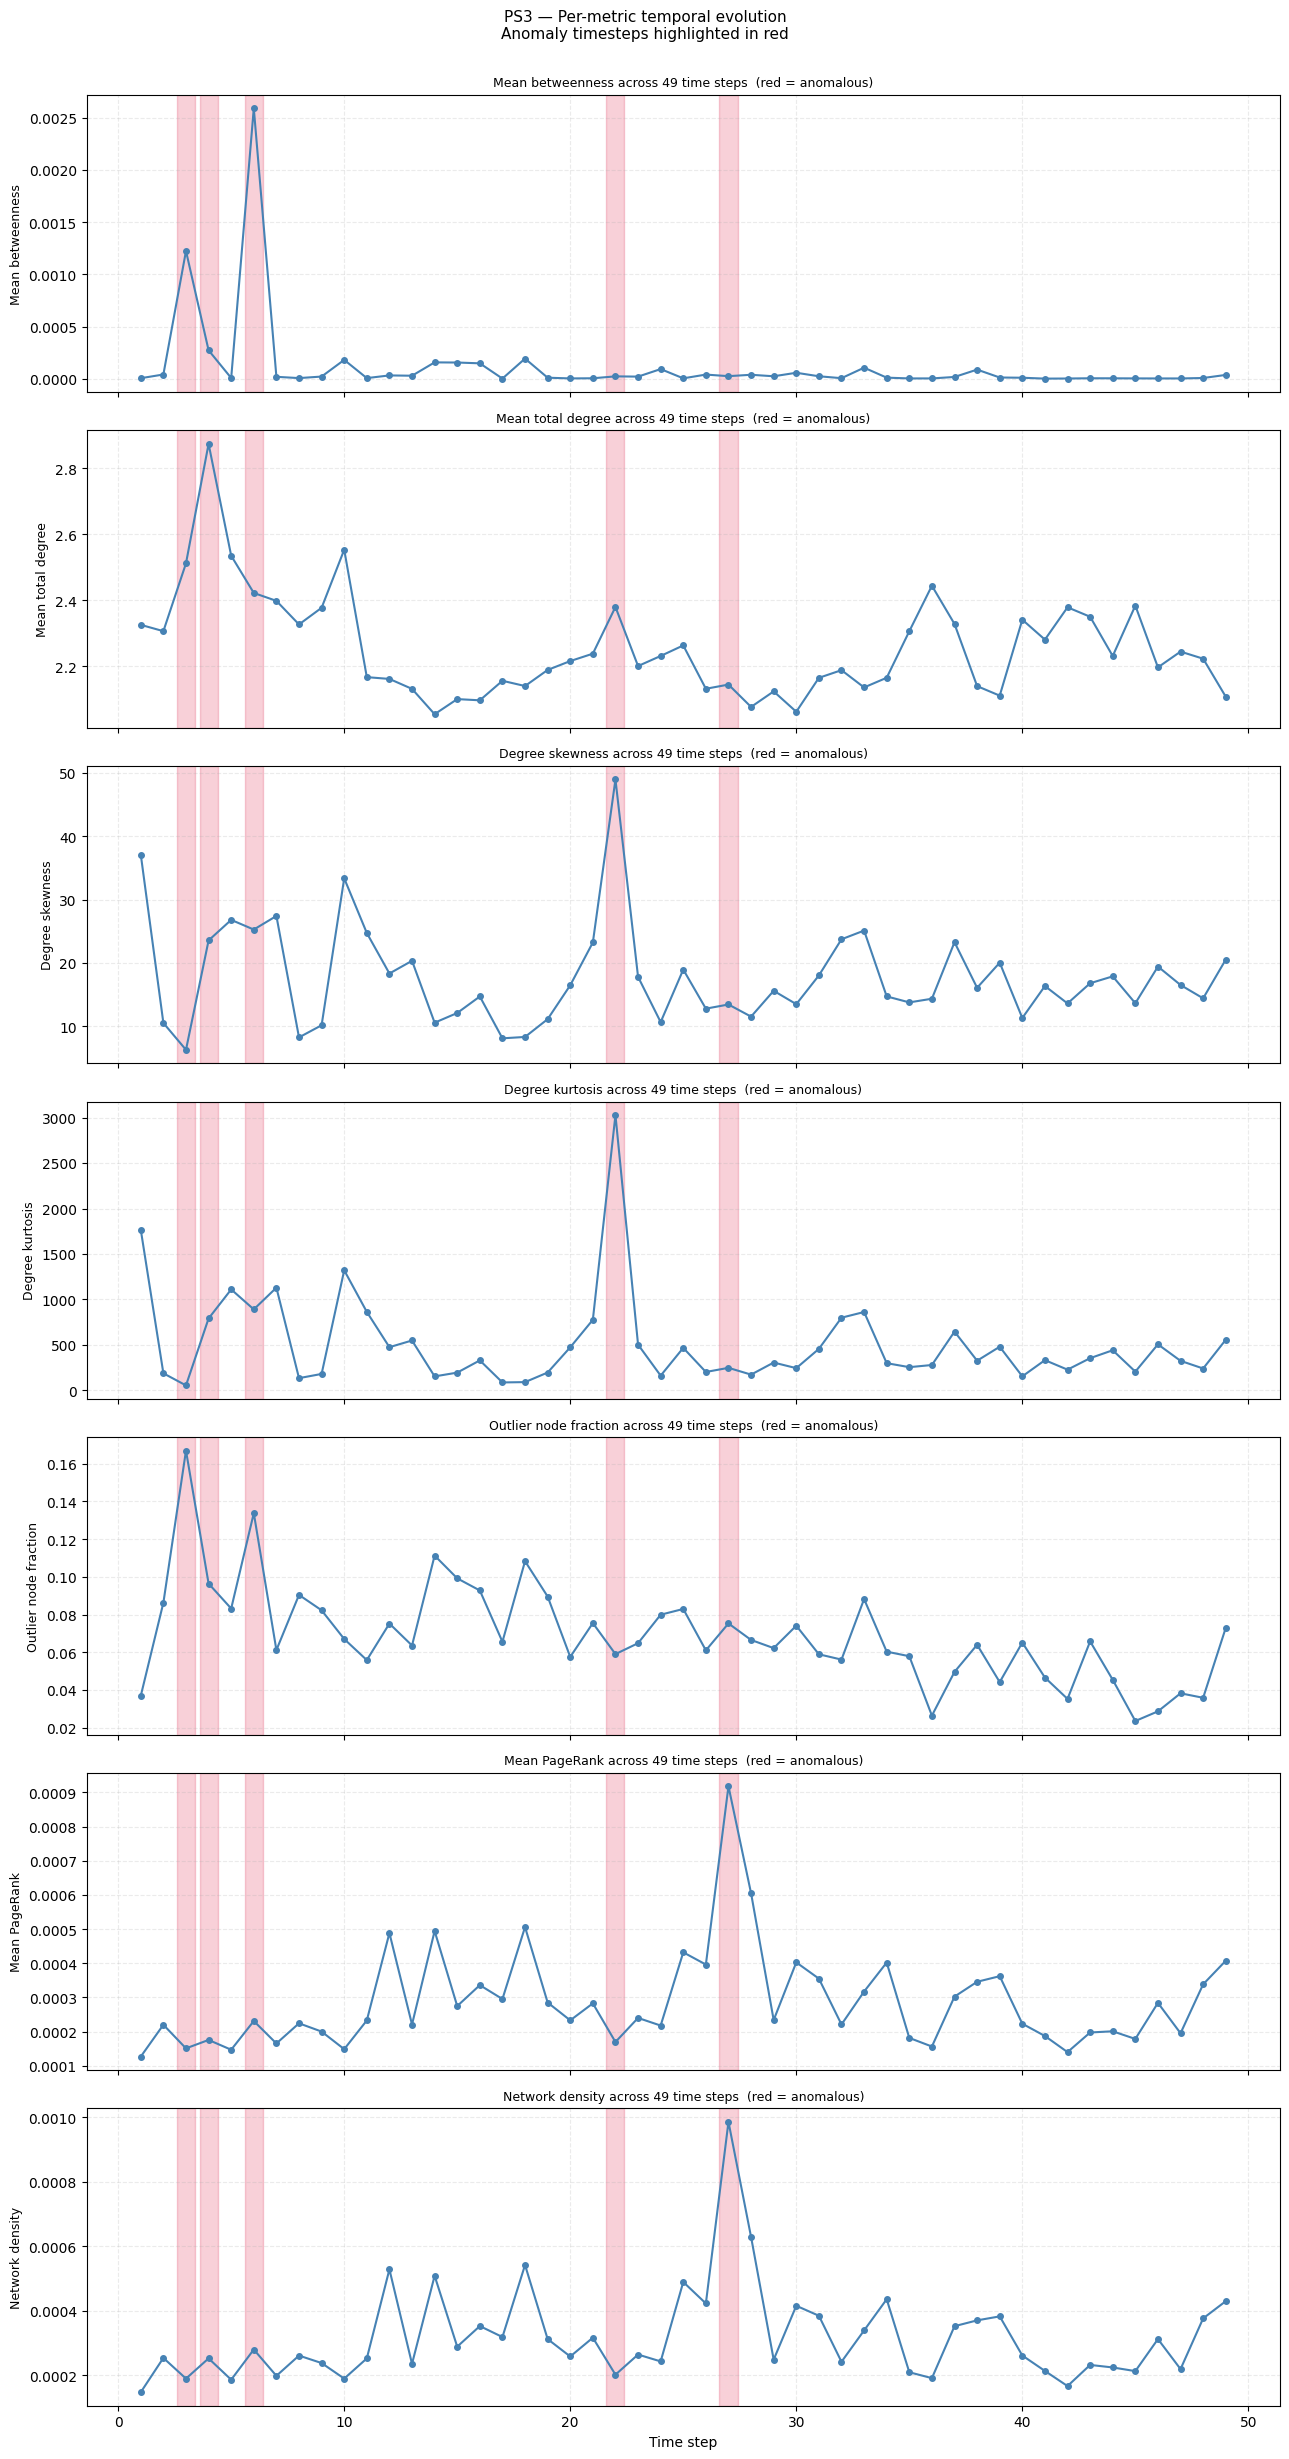

In [20]:
# STEP 10B - LINE PLOTS: individual aggregate metrics across 49 timesteps

metrics_to_plot = {
    "mean_betweenness_t": "Mean betweenness",
    "mean_total_degree_t": "Mean total degree",
    "degree_skewness_t": "Degree skewness",
    "degree_kurtosis_t": "Degree kurtosis",
    "outlier_node_fraction_t": "Outlier node fraction",
    "mean_pagerank_t": "Mean PageRank",
    "density": "Network density",
}

anomaly_ts = timestep_agg_df.loc[timestep_agg_df["timestep_anomaly_flag"] == 1, TIME_COL].tolist()

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(13, 3.5 * len(metrics_to_plot)), sharex=True)

for ax, (col, label) in zip(axes, metrics_to_plot.items()):
    ax.plot(
        timestep_agg_df[TIME_COL],
        timestep_agg_df[col],
        marker="o", markersize=4, linewidth=1.5, color="steelblue"
    )

    # Highlight anomalous timesteps bằng vùng đỏ
    for ts in anomaly_ts:
        ax.axvspan(ts - 0.4, ts + 0.4, color="crimson", alpha=0.2)

    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_title(f"{label} across 49 time steps  (red = anomalous)", fontsize=9)

axes[-1].set_xlabel("Time step")
plt.suptitle("PS3 — Per-metric temporal evolution\nAnomaly timesteps highlighted in red", fontsize=11, y=1.002)
plt.tight_layout()
plt.show()

# STEP 11 - COMPUTE PREDECESSOR AND SUCCESSOR TEMPORAL CONTEXT FEATURES

⚠️ Lưu ý trước: Dataset Elliptic không có edge weights, nên Herfindahl index sẽ dùng degree-based shares thay vì value-based. 

In [21]:
# STEP 11 - ENHANCED CONTEXT FEATURES
# Bao gồm: 2-hop predecessor/successor (giữ từ trước)
#          + cascade_depth (topological depth trong G_t)
#          + anc_count / desc_count per timestep
#          + ts_span_anc (cross-timestep span của ancestors)
#          + herfindahl_in/out (degree-based, vì Elliptic ko có edge weights)

# ── Lookup table: node → metrics ────────────────────────────────────────────
metric_lookup = ps3_node_df.set_index(TX_COL)[
    [TIME_COL, "betweenness_t", "asymmetry_t", "total_degree_t"]
].to_dict("index")

# ── Helper: Herfindahl index (degree-based) ──────────────────────────────────
def herfindahl(degree_list):
    """Sum of squared shares of degree values. Range [1/n, 1].
    = 1 khi chỉ có 1 neighbor, → 0 khi rất nhiều neighbor đều nhau.
    NOTE: Elliptic không có edge weights nên dùng degree làm proxy."""
    if len(degree_list) == 0:
        return 0.0
    total = sum(degree_list)
    if total == 0:
        return 0.0
    return sum((d / total) ** 2 for d in degree_list)

# ── Tính cascade_depth (topological depth) trong toàn bộ G ──────────────────
# Dùng BFS từ các source nodes (in_degree == 0)
print("Computing topological depth for all nodes...")
topo_depth = {}
for n in G.nodes():
    topo_depth[n] = 0  # default

# Kahn's algorithm — O(V+E)
from collections import deque
in_deg_full = dict(G.in_degree())
queue = deque([n for n, d in in_deg_full.items() if d == 0])
while queue:
    node = queue.popleft()
    for succ in G.successors(node):
        new_depth = topo_depth[node] + 1
        if new_depth > topo_depth.get(succ, 0):
            topo_depth[succ] = new_depth
        in_deg_full[succ] -= 1
        if in_deg_full[succ] == 0:
            queue.append(succ)

print(f"Topological depth computed. Max depth: {max(topo_depth.values())}")

# ── Tính ancestor/descendant count per node trong G_t của từng timestep ─────
print("Computing per-timestep ancestor/descendant counts...")
anc_count_dict = {}   # txId → # ancestors within same timestep
desc_count_dict = {}  # txId → # descendants within same timestep

for t in time_steps:
    nodes_t = nodes_by_timestep[t]
    G_t = G.subgraph(nodes_t)
    nodes_set_t = set(nodes_t)

    # Topological sweep để tính ancestor set size
    in_deg_t = dict(G_t.in_degree())
    anc_sets = {n: set() for n in nodes_t}
    queue_t = deque([n for n in nodes_t if in_deg_t[n] == 0])
    in_deg_temp = dict(in_deg_t)  # copy để không modify G_t

    for n in nx.topological_sort(G_t):
        for succ in G_t.successors(n):
            anc_sets[succ] |= anc_sets[n] | {n}

    for n in nodes_t:
        anc_count_dict[n] = len(anc_sets[n])

    # Descendant count: reverse
    desc_sets = {n: set() for n in nodes_t}
    for n in reversed(list(nx.topological_sort(G_t))):
        for pred in G_t.predecessors(n):
            desc_sets[pred] |= desc_sets[n] | {n}

    for n in nodes_t:
        desc_count_dict[n] = len(desc_sets[n])

    gc.collect()

print("Ancestor/descendant counts done.")

# ── Build node-level timestep lookup ─────────────────────────────────────────
node_to_timestep = ps3_node_df.set_index(TX_COL)[TIME_COL].to_dict()

# ── Main loop: build context features ────────────────────────────────────────
context_records = []

for n in G.nodes():
    node_info = metric_lookup.get(n, None)
    if node_info is None:
        continue

    node_t = node_info[TIME_COL]

    # ── 2-hop predecessors ──────────────────────────────────────────────────
    preds_1hop = [p for p in G.predecessors(n) if p in metric_lookup]
    preds_2hop = []
    for p in preds_1hop:
        preds_2hop.extend([pp for pp in G.predecessors(p) if pp in metric_lookup])
    all_preds = list(set(preds_1hop + preds_2hop))

    # ── 2-hop successors ────────────────────────────────────────────────────
    succs_1hop = [s for s in G.successors(n) if s in metric_lookup]
    succs_2hop = []
    for s in succs_1hop:
        succs_2hop.extend([ss for ss in G.successors(s) if ss in metric_lookup])
    all_succs = list(set(succs_1hop + succs_2hop))

    # ── Extract metrics (giống cũ) ──────────────────────────────────────────
    pred_bet  = [metric_lookup[p]["betweenness_t"]  for p in all_preds]
    pred_asym = [metric_lookup[p]["asymmetry_t"]    for p in all_preds]
    pred_deg  = [metric_lookup[p]["total_degree_t"] for p in all_preds]
    succ_bet  = [metric_lookup[s]["betweenness_t"]  for s in all_succs]
    succ_asym = [metric_lookup[s]["asymmetry_t"]    for s in all_succs]
    succ_deg  = [metric_lookup[s]["total_degree_t"] for s in all_succs]

    # ── NEW: Cascade features ───────────────────────────────────────────────

    # Cross-timestep span của ancestors (2-hop)
    pred_timesteps = [node_to_timestep[p] for p in all_preds if p in node_to_timestep]
    if len(pred_timesteps) >= 2:
        ts_span_anc = max(pred_timesteps) - min(pred_timesteps)
    elif len(pred_timesteps) == 1:
        ts_span_anc = 0.0
    else:
        ts_span_anc = 0.0

    succ_timesteps = [node_to_timestep[s] for s in all_succs if s in node_to_timestep]
    if len(succ_timesteps) >= 2:
        ts_span_desc = max(succ_timesteps) - min(succ_timesteps)
    elif len(succ_timesteps) == 1:
        ts_span_desc = 0.0
    else:
        ts_span_desc = 0.0

    # Herfindahl index (degree-based, vì không có edge weights)
    herf_in  = herfindahl(pred_deg)
    herf_out = herfindahl(succ_deg)

    # Flow velocity: cascade_depth / max(ts_span_anc, 1)
    c_depth = topo_depth.get(n, 0)
    flow_vel = c_depth / max(ts_span_anc, 1.0)

    context_records.append({
        TX_COL: n,

        # === Giữ từ version cũ ===
        "count_predecessors_2hop": len(all_preds),
        "count_successors_2hop":   len(all_succs),
        "mean_predecessor_betweenness_t": np.mean(pred_bet)  if pred_bet  else 0.0,
        "mean_predecessor_asymmetry_t":  np.mean(pred_asym) if pred_asym else 0.0,
        "std_predecessor_degree_t":      np.std(pred_deg, ddof=0) if len(pred_deg) > 1 else 0.0,
        "mean_successor_betweenness_t":  np.mean(succ_bet)  if succ_bet  else 0.0,
        "mean_successor_asymmetry_t":    np.mean(succ_asym) if succ_asym else 0.0,
        "std_successor_degree_t":        np.std(succ_deg, ddof=0) if len(succ_deg) > 1 else 0.0,

        # === Features mới ===
        "anc_count_t":    anc_count_dict.get(n, 0),   # ancestors trong cùng timestep
        "desc_count_t":   desc_count_dict.get(n, 0),  # descendants trong cùng timestep
        "cascade_depth":  c_depth,                     # topological depth trong full G
        "ts_span_anc":    ts_span_anc,                 # cross-timestep span ancestors
        "ts_span_desc":   ts_span_desc,                # cross-timestep span descendants
        "herfindahl_in":  herf_in,                     # funnelling concentration (in)
        "herfindahl_out": herf_out,                    # dispersal concentration (out)
        "flow_velocity":  flow_vel,                    # cascade_depth / ts_span_anc
    })

context_df = pd.DataFrame(context_records)
print("context_df shape:", context_df.shape)
display(context_df.head())

Computing topological depth for all nodes...
Topological depth computed. Max depth: 1248
Computing per-timestep ancestor/descendant counts...
Ancestor/descendant counts done.
context_df shape: (203769, 17)


,txId,count_predecessors_2hop,count_successors_2hop,mean_predecessor_betweenness_t,mean_predecessor_asymmetry_t,std_predecessor_degree_t,mean_successor_betweenness_t,mean_successor_asymmetry_t,std_successor_degree_t,anc_count_t,desc_count_t,cascade_depth,ts_span_anc,ts_span_desc,herfindahl_in,herfindahl_out,flow_velocity
0,230425980,2,2,7.618052e-07,-0.166667,0.500000,1.269358e-07,0.500000,0.500000,7,2,7,0.0,0.0,0.520000,0.555556,7.0
1,5530458,2,1,4.444658e-07,0.000000,0.000000,0.000000e+00,1.000000,0.000000,8,1,8,0.0,0.0,0.500000,1.000000,8.0
2,232022460,2,4,0.000000e+00,0.000000,0.000000,1.727279e-05,0.246894,68.849020,3,10,3,0.0,0.0,0.500000,0.929865,3.0
3,232438397,289,2,4.370737e-07,-0.393613,16.967351,2.710079e-05,0.000000,0.000000,471,5,13,0.0,0.0,0.081279,0.500000,13.0
4,230460314,3,20,0.000000e+00,-0.740741,1.414214,2.492404e-06,0.378586,6.373971,3,68,3,0.0,0.0,0.343750,0.100378,3.0


In [22]:
# STEP 11 - EXPORT FULL CONTEXT DATA

OUTPUT_CONTEXT = "/kaggle/working/ps3_step11_full.csv"

context_df.to_csv(OUTPUT_CONTEXT, index=False)

print("Saved FULL context file to:", OUTPUT_CONTEXT)
print("Shape:", context_df.shape)

display(context_df.head())

Saved FULL context file to: /kaggle/working/ps3_step11_full.csv
Shape: (203769, 17)


,txId,count_predecessors_2hop,count_successors_2hop,mean_predecessor_betweenness_t,mean_predecessor_asymmetry_t,std_predecessor_degree_t,mean_successor_betweenness_t,mean_successor_asymmetry_t,std_successor_degree_t,anc_count_t,desc_count_t,cascade_depth,ts_span_anc,ts_span_desc,herfindahl_in,herfindahl_out,flow_velocity
0,230425980,2,2,7.618052e-07,-0.166667,0.500000,1.269358e-07,0.500000,0.500000,7,2,7,0.0,0.0,0.520000,0.555556,7.0
1,5530458,2,1,4.444658e-07,0.000000,0.000000,0.000000e+00,1.000000,0.000000,8,1,8,0.0,0.0,0.500000,1.000000,8.0
2,232022460,2,4,0.000000e+00,0.000000,0.000000,1.727279e-05,0.246894,68.849020,3,10,3,0.0,0.0,0.500000,0.929865,3.0
3,232438397,289,2,4.370737e-07,-0.393613,16.967351,2.710079e-05,0.000000,0.000000,471,5,13,0.0,0.0,0.081279,0.500000,13.0
4,230460314,3,20,0.000000e+00,-0.740741,1.414214,2.492404e-06,0.378586,6.373971,3,68,3,0.0,0.0,0.343750,0.100378,3.0


# STEP 12 - MERGE ALL PS3 FEATURES WITH LABELS

In [23]:
ps3_df = (
    ps3_node_df
    .merge(context_df, on=TX_COL, how="left")
    .merge(
        timestep_agg_df[
            [TIME_COL, "timestep_anomaly_score", "timestep_anomaly_flag"] + agg_metric_cols
        ],
        on=TIME_COL,
        how="left"
    )
    .merge(
        base_df[[TX_COL, RAW_CLASS_COL, CLASS_LABEL_COL]],
        on=TX_COL,
        how="left"
    )
)

print("ps3_df shape:", ps3_df.shape)
display(ps3_df.head())

ps3_df shape: (203769, 52)


,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,bet_stability_range_t,pagerank_t,clustering_t,wcc_size_t,z_betweenness_t,z_degree_t,z_asymmetry_t,z_pagerank_t,flag_z_betweenness_t,flag_z_degree_t,flag_z_asymmetry_t,flag_z_pagerank_t,outlier_flag_count_t,within_timestep_outlier,count_predecessors_2hop,count_successors_2hop,mean_predecessor_betweenness_t,mean_predecessor_asymmetry_t,std_predecessor_degree_t,mean_successor_betweenness_t,mean_successor_asymmetry_t,std_successor_degree_t,anc_count_t,desc_count_t,cascade_depth,ts_span_anc,ts_span_desc,herfindahl_in,herfindahl_out,flow_velocity,timestep_anomaly_score,timestep_anomaly_flag,mean_betweenness_t,mean_total_degree_t,mean_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,density,n_weak_components,class,class_label
0,4947969,1,1,1,2,0.0,0.0,0.000006,0.000019,0.000228,0.0,7880,0.030500,-0.065959,0.122723,0.438545,0,0,0,0,0,0,2,2,0.000007,0.0,0.0,0.000009,0.0,0.0,15,50,14,0.0,0.0,0.5,0.5,14.0,2.501871,0,0.000005,2.325888,-0.077162,0.000127,0.375,0.036929,37.105762,1766.369856,0.000148,1,unknown,unknown
1,4947974,1,1,1,2,0.0,0.0,0.000006,0.000019,0.000233,0.0,7880,0.026215,-0.065959,0.122723,0.459605,0,0,0,0,0,0,2,2,0.000006,0.0,0.0,0.000012,0.0,0.0,16,49,15,0.0,0.0,0.5,0.5,15.0,2.501871,0,0.000005,2.325888,-0.077162,0.000127,0.375,0.036929,37.105762,1766.369856,0.000148,1,unknown,unknown
2,4947979,1,1,1,2,0.0,0.0,0.000016,0.000022,0.000247,0.0,7880,0.386529,-0.065959,0.122723,0.520730,0,0,0,0,0,0,2,2,0.000017,0.0,0.0,0.000016,0.0,0.0,22,43,21,0.0,0.0,0.5,0.5,21.0,2.501871,0,0.000005,2.325888,-0.077162,0.000127,0.375,0.036929,37.105762,1766.369856,0.000148,1,unknown,unknown
3,82706446,1,1,0,1,1.0,1.0,0.000000,0.000000,0.000123,0.0,7880,-0.194834,-0.268355,1.713188,-0.018527,0,0,0,0,0,0,2,0,0.000000,0.0,0.0,0.000000,0.0,0.0,4,0,4,0.0,0.0,0.5,0.0,4.0,2.501871,0,0.000005,2.325888,-0.077162,0.000127,0.375,0.036929,37.105762,1766.369856,0.000148,1,2,licit
4,4947982,1,1,1,2,0.0,0.0,0.000016,0.000027,0.000247,0.0,7880,0.373009,-0.065959,0.122723,0.520730,0,0,0,0,0,0,2,2,0.000017,0.0,0.0,0.000015,0.0,0.0,23,42,22,0.0,0.0,0.5,0.5,22.0,2.501871,0,0.000005,2.325888,-0.077162,0.000127,0.375,0.036929,37.105762,1766.369856,0.000148,1,unknown,unknown


# Step 12B – Focused betweenness-based timestep score

In [24]:
# Step 10F – Focused betweenness-based timestep score

from scipy.stats import zscore, spearmanr
import numpy as np
import pandas as pd

# Copy timestep table
focused_ts = timestep_agg_df.copy()

# Metric 1: mean betweenness
# Metric 2: fraction of betweenness outliers per timestep
betw_outlier_by_t = (
    ps3_df.groupby(TIME_COL)["flag_z_betweenness_t"]
    .mean()
    .reset_index(name="betweenness_outlier_fraction_t")
)

focused_ts = focused_ts.merge(betw_outlier_by_t, on=TIME_COL, how="left")

selected_metrics = [
    "mean_betweenness_t",
    "betweenness_outlier_fraction_t"
]

# z-score selected metrics across 49 timesteps
for col in selected_metrics:
    focused_ts[f"z_{col}"] = zscore(focused_ts[col].fillna(0), nan_policy="omit")

# focused anomaly score
focused_ts["focused_betweenness_anomaly_score"] = (
    focused_ts[[f"z_{c}" for c in selected_metrics]]
    .mean(axis=1)
)

# merge labelled illicit fraction per timestep
label_ts = (
    ps3_df[ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"])]
    .groupby(TIME_COL)
    .agg(
        labelled_nodes=(CLASS_LABEL_COL, "size"),
        illicit_nodes=(CLASS_LABEL_COL, lambda x: (x == "illicit").sum())
    )
    .reset_index()
)

label_ts["illicit_fraction_t"] = (
    label_ts["illicit_nodes"] / label_ts["labelled_nodes"]
)

focused_ts = focused_ts.merge(label_ts, on=TIME_COL, how="left")

# Spearman correlation
rho_obs, p_asym = spearmanr(
    focused_ts["focused_betweenness_anomaly_score"],
    focused_ts["illicit_fraction_t"],
    nan_policy="omit"
)

print("Observed Spearman rho:", rho_obs)
print("Asymptotic p-value:", p_asym)

# permutation p-value
rng = np.random.default_rng(42)
valid = focused_ts[
    ["focused_betweenness_anomaly_score", "illicit_fraction_t"]
].dropna()

obs_rho, _ = spearmanr(
    valid["focused_betweenness_anomaly_score"],
    valid["illicit_fraction_t"]
)

null_rhos = []
for _ in range(1000):
    shuffled = rng.permutation(valid["illicit_fraction_t"].values)
    rho_b, _ = spearmanr(valid["focused_betweenness_anomaly_score"], shuffled)
    null_rhos.append(rho_b)

null_rhos = np.array(null_rhos)
p_perm = (np.sum(null_rhos >= obs_rho) + 1) / (len(null_rhos) + 1)

print("Permutation p-value:", p_perm)

# Top-k timestep enrichment
baseline = (
    ps3_df[CLASS_LABEL_COL].eq("illicit").sum()
    / ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"]).sum()
)

for k in [5, 10, 15]:
    top_t = focused_ts.nlargest(k, "focused_betweenness_anomaly_score")
    labelled = top_t["labelled_nodes"].sum()
    illicit = top_t["illicit_nodes"].sum()
    illicit_rate = illicit / labelled
    enrichment = illicit_rate / baseline

    print(f"\nTop {k} timesteps")
    print("Labelled nodes:", labelled)
    print("Illicit nodes:", illicit)
    print("Illicit rate:", illicit_rate)
    print("Enrichment:", enrichment)

Observed Spearman rho: 0.18530612244897957
Asymptotic p-value: 0.20240472811132637
Permutation p-value: 0.1068931068931069

Top 5 timesteps
Labelled nodes: 3188
Illicit nodes: 258
Illicit rate: 0.0809284818067754
Enrichment: 0.82912075398255

Top 10 timesteps
Labelled nodes: 7316
Illicit nodes: 537
Illicit rate: 0.07340076544559869
Enrichment: 0.7519985131372624

Top 15 timesteps
Labelled nodes: 10542
Illicit nodes: 947
Illicit rate: 0.08983115158413964
Enrichment: 0.9203295362736805


# **EVALUATE**

# STEP 13 - COMPUTE THE BASELINE ILLICIT RATE

In [25]:
labeled_all = ps3_df[ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all[CLASS_LABEL_COL] == "illicit").mean()

print("Baseline illicit rate:", baseline_illicit)
print(labeled_all[CLASS_LABEL_COL].value_counts())

Baseline illicit rate: 0.09760759384932566
class_label
licit      42019
illicit     4545
Name: count, dtype: int64


# STEP 14 - EVALUATE WITHIN-TIMESTEP OUTLIER ENRICHMENT

- xem node outlier có nhiều illicit hơn không
- Chọn 1 nhóm node → tính % illicit → so với baseline → xem có "enrich" không


In [26]:
# Hàm enrichment_ratio
def enrichment_ratio(df_subset, class_col=CLASS_LABEL_COL, positive_label="illicit", baseline=0.0):
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()

    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "actual_illicit_count": 0,
            "expected_illicit_count": np.nan,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan,
            "lift_count": np.nan
        }

    actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
    illicit_rate_subset = actual_illicit_count / len(labeled_subset)
    expected_illicit_count = baseline * len(labeled_subset) if baseline > 0 else np.nan
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    lift_count = actual_illicit_count - expected_illicit_count if baseline > 0 else np.nan

    return {
        "n_subset_labeled": len(labeled_subset),
        "actual_illicit_count": actual_illicit_count,
        "expected_illicit_count": expected_illicit_count,
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment,
        "lift_count": lift_count
    }

# overall within-timestep outliers
outlier_subset = ps3_df[ps3_df["within_timestep_outlier"] == 1].copy()    # lấy các node có ít nhất 1 metric bị lệch mạnh (|z| > 2)
outlier_enrichment = pd.DataFrame([enrichment_ratio(outlier_subset, baseline=baseline_illicit)])
display(outlier_enrichment)

# by each z-based flag
outlier_by_metric = []
for c in flag_cols:     # loop qua từng loại outlier: z_betweenness, z_degree, z_asymmetry, z_pagerank
    subset = ps3_df[ps3_df[c] == 1].copy()
    res = enrichment_ratio(subset, baseline=baseline_illicit)
    res["flag_metric"] = c
    outlier_by_metric.append(res)

outlier_by_metric_df = pd.DataFrame(outlier_by_metric)
display(outlier_by_metric_df.sort_values("enrichment_ratio", ascending=False))



# Multiple testing correction cho 4 flag metrics
from scipy.stats import binomtest

n_tests = len(flag_cols)  # = 4
alpha_bonferroni = 0.05 / n_tests  # = 0.0125

print(f"\n=== MULTIPLE TESTING CORRECTION (Bonferroni, {n_tests} metrics) ===")
print(f"Adjusted alpha per metric: {alpha_bonferroni:.4f}")

for _, row in outlier_by_metric_df.iterrows():
    n_sub = int(row["n_subset_labeled"])
    n_ill = int(row["actual_illicit_count"])
    if n_sub == 0:
        continue
    # Binomial test: apakah illicit rate > baseline?
    p_val = binomtest(n_ill, n_sub, baseline_illicit, alternative="greater").pvalue
    sig = "✓ significant" if p_val < alpha_bonferroni else "✗ not significant"
    print(f"  {row['flag_metric']:30s}: enrichment={row['enrichment_ratio']:.2f}x, "
          f"p={p_val:.4f}  {sig}")

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,3007,270,293.506035,0.08979,0.097608,0.919913,-23.506035


,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,flag_metric
0,821,226,80.135835,0.275274,0.097608,2.820211,145.864165,flag_z_betweenness_t
3,1510,38,147.387467,0.025166,0.097608,0.257824,-109.387467,flag_z_pagerank_t
1,1643,27,160.369277,0.016433,0.097608,0.168361,-133.369277,flag_z_degree_t
2,269,4,26.256443,0.014870,0.097608,0.152344,-22.256443,flag_z_asymmetry_t



=== MULTIPLE TESTING CORRECTION (Bonferroni, 4 metrics) ===
Adjusted alpha per metric: 0.0125
  flag_z_betweenness_t          : enrichment=2.82x, p=0.0000  ✓ significant
  flag_z_degree_t               : enrichment=0.17x, p=1.0000  ✗ not significant
  flag_z_asymmetry_t            : enrichment=0.15x, p=1.0000  ✗ not significant
  flag_z_pagerank_t             : enrichment=0.26x, p=1.0000  ✗ not significant


In [27]:
# ── HEADLINE RESULT: chỉ betweenness outlier ──────────────────
print("=== HEADLINE: Betweenness outlier enrichment ===")
bet_outlier_subset = ps3_df[ps3_df["flag_z_betweenness_t"] == 1]
bet_enrichment = pd.DataFrame([enrichment_ratio(bet_outlier_subset, baseline=baseline_illicit)])
display(bet_enrichment)

# ── Overall outlier (ALL flags) — giữ để so sánh ──────────────
print("=== COMPARISON: All-metric outlier enrichment ===")
display(outlier_enrichment)  # 0.96x — ghi chú rõ đây là bị pha loãng

# ── Giải thích trong comment ───────────────────────────────────
# Betweenness outlier: enrichment = 3.02x → headline finding
# All-metric union:    enrichment = 0.96x → bị pha loãng bởi degree/pagerank/asymmetry outliers
# Kết luận: chỉ betweenness z-score là discriminative signal trong PS3

=== HEADLINE: Betweenness outlier enrichment ===


,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,821,226,80.135835,0.275274,0.097608,2.820211,145.864165


=== COMPARISON: All-metric outlier enrichment ===


,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,3007,270,293.506035,0.08979,0.097608,0.919913,-23.506035


# STEP 14C - LABEL COVERAGE FOR BETWEENNESS OUTLIER

In [28]:
# STEP 14C - LABEL COVERAGE FOR BETWEENNESS OUTLIER
bet_outlier_all = ps3_df[ps3_df["flag_z_betweenness_t"] == 1]
n_total = len(bet_outlier_all)
n_labeled = bet_outlier_all[CLASS_LABEL_COL].isin(["licit","illicit"]).sum()
pct_labeled = n_labeled / n_total * 100

print(f"Betweenness outlier nodes : {n_total}")
print(f"Labeled                   : {n_labeled} ({pct_labeled:.1f}%)")
print(f"Action: {'OK' if n_labeled >= 30 else 'INSUFFICIENT DATA'}")

Betweenness outlier nodes : 9037
Labeled                   : 821 (9.1%)
Action: OK


# STEP 14D - BOOTSTRAP CI + PERMUTATION NULL FOR 3× ENRICHMENT HEADLINE

In [29]:
# STEP 14D - BOOTSTRAP CI + PERMUTATION NULL FOR 3× ENRICHMENT HEADLINE
# Task 5: Làm cho con số 3× enrichment có thể cite được
# Format chuẩn theo Evaluation Contract:
#   metric = point_estimate [CI_low, CI_high]
#   permutation p-value: xxx (1000 shuffles)
#   labelled-N in evaluation set: NN

np.random.seed(SEED)
N_BOOTSTRAP = 1000
N_PERMUTATION = 1000

labeled_mask = ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"])
bet_outlier_mask = ps3_df["flag_z_betweenness_t"] == 1

# ── Dữ liệu gốc để tính ────────────────────────────────────────────────────
subset_labeled = ps3_df[bet_outlier_mask & labeled_mask].copy()
n_labeled_in_subset = len(subset_labeled)
observed_illicit_rate = (subset_labeled[CLASS_LABEL_COL] == "illicit").mean()
observed_enrichment = observed_illicit_rate / baseline_illicit

print(f"=== HEADLINE: Betweenness outlier enrichment ===")
print(f"Labelled-N in evaluation set : {n_labeled_in_subset}")
print(f"Observed illicit rate        : {observed_illicit_rate:.4f}")
print(f"Baseline illicit rate        : {baseline_illicit:.4f}")
print(f"Observed enrichment ratio    : {observed_enrichment:.4f}x")

# ── Bootstrap CI ────────────────────────────────────────────────────────────
boot_enrichments = []
for _ in range(N_BOOTSTRAP):
    boot_sample = subset_labeled.sample(n=n_labeled_in_subset, replace=True)
    boot_rate = (boot_sample[CLASS_LABEL_COL] == "illicit").mean()
    boot_enrichments.append(boot_rate / baseline_illicit)

ci_low  = np.percentile(boot_enrichments, 2.5)
ci_high = np.percentile(boot_enrichments, 97.5)

# ── Permutation null ─────────────────────────────────────────────────────────
# Shuffle labels trong toàn bộ labeled set, giữ marginal counts
all_labeled = ps3_df[labeled_mask].copy()
n_labeled_total = len(all_labeled)
perm_enrichments = []

for _ in range(N_PERMUTATION):
    shuffled_labels = all_labeled[CLASS_LABEL_COL].sample(
        frac=1, replace=False
    ).values
    # Lấy cùng indices như bet_outlier subset
    perm_subset_labels = shuffled_labels[
        all_labeled.index.isin(subset_labeled.index)
    ]

    perm_rate = (perm_subset_labels == "illicit").mean()
    perm_enrichments.append(perm_rate / baseline_illicit)

perm_p_value = np.mean(np.array(perm_enrichments) >= observed_enrichment)

# ── Approximation stability note ────────────────────────────────────────────
# (betweenness đã dùng median 3 seeds trong Step 7)
all_bet_ranges = ps3_node_df["bet_stability_range_t"] if "bet_stability_range_t" in ps3_node_df.columns else None

print(f"\n=== EVALUATION CONTRACT FORMAT ===")
print(f"enrichment_ratio = {observed_enrichment:.3f}x  [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  permutation p-value : {perm_p_value:.4f}  ({N_PERMUTATION} shuffles)")
if all_bet_ranges is not None:
    bet_outlier_nodes = ps3_node_df[ps3_node_df["flag_z_betweenness_t"] == 1]
    med_range = bet_outlier_nodes["bet_stability_range_t"].median()
    print(f"  approximation stability : median seed-range = {med_range:.6f}  (3 seeds: 42, 7, 123)")
print(f"  labelled-N in evaluation set : {n_labeled_in_subset}")

if perm_p_value < 0.01:
    print("\n✓ PASS — enrichment is statistically significant (p < 0.01)")
else:
    print(f"\n✗ NOTE — enrichment p-value = {perm_p_value:.4f}, interpret with caution")

=== HEADLINE: Betweenness outlier enrichment ===
Labelled-N in evaluation set : 821
Observed illicit rate        : 0.2753
Baseline illicit rate        : 0.0976
Observed enrichment ratio    : 2.8202x

=== EVALUATION CONTRACT FORMAT ===
enrichment_ratio = 2.820x  [2.508, 3.157]
  permutation p-value : 0.0000  (1000 shuffles)
  approximation stability : median seed-range = 0.000087  (3 seeds: 42, 7, 123)
  labelled-N in evaluation set : 821

✓ PASS — enrichment is statistically significant (p < 0.01)


# **MANN-WHITNEY TEST**

In [30]:
# STEP 14B - MANN-WHITNEY TEST FOR PS3 Z-SCORE METRICS

def mannwhitney_with_rbc(df, metric_col, class_col=CLASS_LABEL_COL):
    sub = df[df[class_col].isin(["licit", "illicit"])][[metric_col, class_col]].dropna()
    x = sub.loc[sub[class_col] == "illicit", metric_col].values  # illicit
    y = sub.loc[sub[class_col] == "licit",   metric_col].values  # licit
    u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
    rbc = (2 * u_stat) / (len(x) * len(y)) - 1
    return {
        "metric": metric_col,
        "n_illicit": len(x),
        "n_licit": len(y),
        "u_stat": u_stat,
        "p_value": p_value,
        "rank_biserial_corr": rbc,
        "median_illicit": np.median(x),
        "median_licit": np.median(y),
    }

ps3_mw_metrics = [
    "z_betweenness_t", "z_degree_t", "z_pagerank_t",
    "mean_predecessor_betweenness_t", "mean_predecessor_asymmetry_t"
]

ps3_mw_results = pd.DataFrame([mannwhitney_with_rbc(ps3_df, m) for m in ps3_mw_metrics])
display(ps3_mw_results)

,metric,n_illicit,n_licit,u_stat,p_value,rank_biserial_corr,median_illicit,median_licit
0,z_betweenness_t,4545,42019,83669820.0,6.603451e-43,-0.123768,-0.282321,-0.266328
1,z_degree_t,4545,42019,73592236.0,1.001949e-142,-0.229305,-0.224115,-0.084961
2,z_pagerank_t,4545,42019,90617655.5,1.532684e-08,-0.051007,-0.265699,-0.267154
3,mean_predecessor_betweenness_t,4545,42019,90180980.0,4.743542e-14,-0.055580,0.000000,0.000000
4,mean_predecessor_asymmetry_t,4545,42019,89623022.5,1.532794e-12,-0.061423,-0.416667,-0.250000


# STEP 15 - EVALUATE ANOMALOUS TIMESTEP ENRICHMENT

xem timestep bất thường có nhiều illicit hơn không

In [31]:
# illicit fraction per timestep (labeled only)
timestep_label_eval_df = (
    ps3_df[ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"])]
    .groupby(TIME_COL)
    .agg(
        n_labeled_t = (CLASS_LABEL_COL, "size"),
        illicit_count_t = (CLASS_LABEL_COL, lambda s: (s == "illicit").sum()),
        illicit_fraction_t = (CLASS_LABEL_COL, lambda s: (s == "illicit").mean())
    )
    .reset_index()
)

timestep_eval_df = timestep_agg_df.merge(timestep_label_eval_df, on=TIME_COL, how="left")

# compare anomalous vs non-anomalous timesteps
anom_steps = timestep_eval_df[timestep_eval_df["timestep_anomaly_flag"] == 1]
non_anom_steps = timestep_eval_df[timestep_eval_df["timestep_anomaly_flag"] == 0]

anomalous_timestep_summary = pd.DataFrame({
    "group": ["anomalous", "non_anomalous"],
    "n_timesteps": [len(anom_steps), len(non_anom_steps)],
    "mean_illicit_fraction": [
        anom_steps["illicit_fraction_t"].mean(),
        non_anom_steps["illicit_fraction_t"].mean()
    ],
    "median_illicit_fraction": [
        anom_steps["illicit_fraction_t"].median(),
        non_anom_steps["illicit_fraction_t"].median()
    ]
})

display(anomalous_timestep_summary)

# Spearman correlation: anomaly score vs illicit fraction
rho, pval = spearmanr(
    timestep_eval_df["timestep_anomaly_score"],
    timestep_eval_df["illicit_fraction_t"],
    nan_policy="omit"
)

print("Spearman rho:", rho)
print("Spearman p-value:", pval)

,group,n_timesteps,mean_illicit_fraction,median_illicit_fraction
0,anomalous,5,0.049174,0.020833
1,non_anomalous,44,0.120784,0.105250


Spearman rho: -0.351938775510204
Spearman p-value: 0.013142713269626502


In [32]:
# NOTE: timestep anomaly detector failed null calibration (Step 10B)
# Spearman rho = -0.347 reported as DESCRIPTIVE ONLY — not a confirmed finding
print("NOTE: Spearman correlation is descriptive only.")
print("Anomaly detector failed null calibration → correlation not a substantive finding.")

NOTE: Spearman correlation is descriptive only.
Anomaly detector failed null calibration → correlation not a substantive finding.


# STEP 15B - PARTIAL SPEARMAN: kiểm soát label coverage

In [33]:
# STEP 15B - PARTIAL SPEARMAN: kiểm soát label coverage
# Task 7: Spearman rho = -0.347 có phải artifact của label coverage không?
# Partial Spearman: tính correlation giữa anomaly_score và illicit_fraction
# SAU KHI đã loại bỏ ảnh hưởng của labeled_fraction

from scipy.stats import spearmanr

# Chuẩn bị data
partial_df = timestep_eval_df[
    ["timestep_anomaly_score", "illicit_fraction_t", "n_labeled_t"]
].dropna().copy()

# Biến thứ 3: tỷ lệ labeled per timestep
partial_df["labeled_fraction_t"] = partial_df["n_labeled_t"] / partial_df["n_labeled_t"].sum()

X = partial_df["timestep_anomaly_score"].values
Y = partial_df["illicit_fraction_t"].values
Z = partial_df["labeled_fraction_t"].values  # covariate cần kiểm soát

# Partial Spearman bằng residual method:
# 1. Rank tất cả
from scipy.stats import rankdata

def partial_spearman(x, y, z):
    """Tính partial Spearman(x, y | z) bằng residual method."""
    rx = rankdata(x).astype(float)
    ry = rankdata(y).astype(float)
    rz = rankdata(z).astype(float)

    # Residuals của rx ~ rz và ry ~ rz (OLS)
    def ols_residuals(a, b):
        slope = np.cov(a, b)[0, 1] / np.var(b)
        intercept = np.mean(a) - slope * np.mean(b)
        return a - (slope * b + intercept)

    res_rx = ols_residuals(rx, rz)
    res_ry = ols_residuals(ry, rz)

    rho, pval = spearmanr(res_rx, res_ry)
    return rho, pval

partial_rho, partial_pval = partial_spearman(X, Y, Z)

# So sánh với Spearman gốc
rho_raw, pval_raw = spearmanr(X, Y, nan_policy="omit")

print("=== PARTIAL SPEARMAN — LABEL COVERAGE CONTROL ===")
print(f"Raw Spearman (anomaly_score vs illicit_fraction)  : rho = {rho_raw:.3f}, p = {pval_raw:.4f}")
print(f"Partial Spearman (controlling for labeled_fraction): rho = {partial_rho:.3f}, p = {partial_pval:.4f}")
print()

if abs(partial_rho) < abs(rho_raw) * 0.5:
    print("⚠ WARNING: Partial correlation substantially weaker than raw.")
    print("  → Temporal correlation claim may be a label-coverage artifact.")
    print("  → ACTION: Retract temporal-correlation claim in thesis.")
    print("  → Spearman is DESCRIPTIVE ONLY — report as observation, not finding.")
else:
    print("✓ Correlation survives label-coverage control.")
    print(f"  Partial rho = {partial_rho:.3f} — temporal signal is robust.")

=== PARTIAL SPEARMAN — LABEL COVERAGE CONTROL ===
Raw Spearman (anomaly_score vs illicit_fraction)  : rho = -0.352, p = 0.0131
Partial Spearman (controlling for labeled_fraction): rho = -0.414, p = 0.0031

✓ Correlation survives label-coverage control.
  Partial rho = -0.414 — temporal signal is robust.


# STEP 16 - PLOT THREE-WAY DISTRIBUTIONS AND TEMPORAL PATTERNS

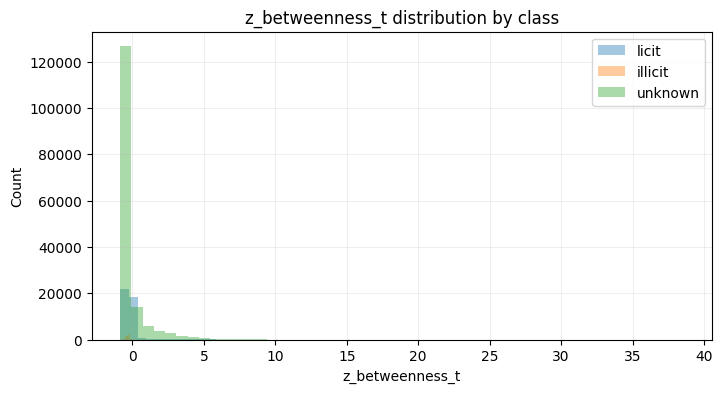

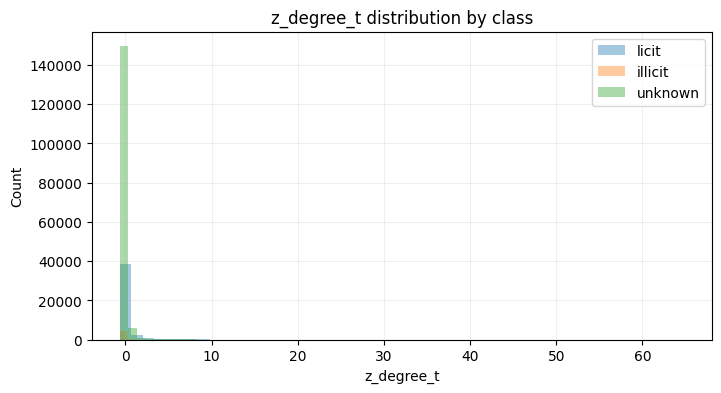

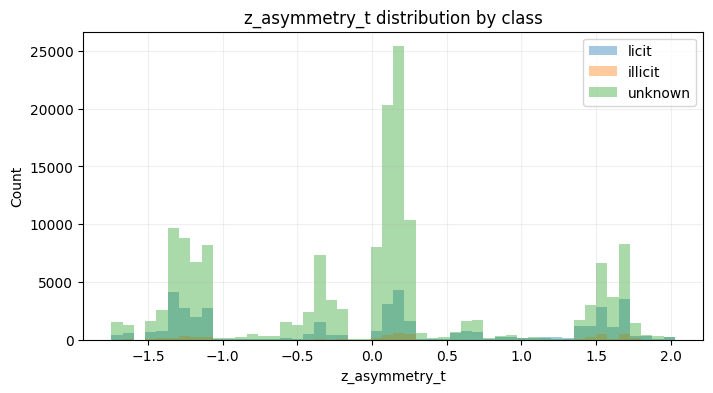

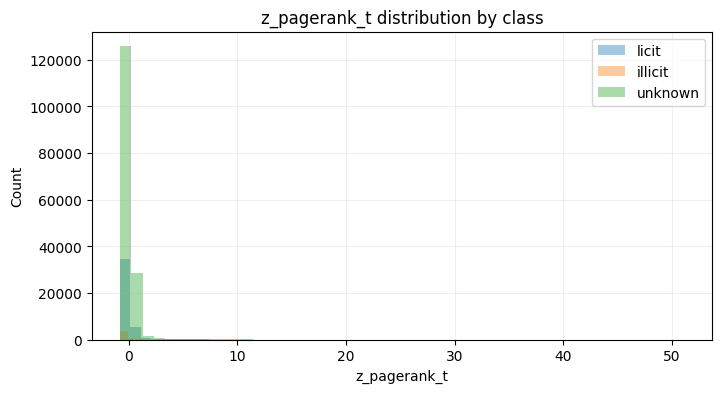

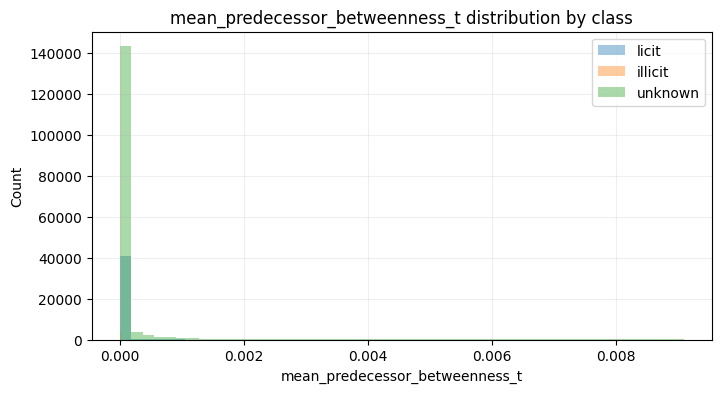

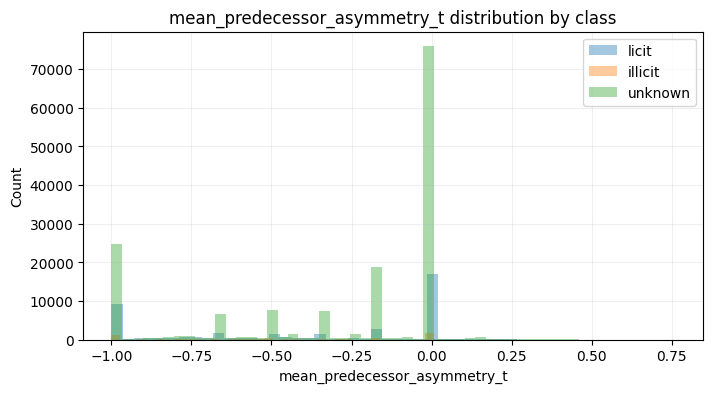

In [34]:
# three-way robustness check
plot_metrics = [
    "z_betweenness_t",
    "z_degree_t",
    "z_asymmetry_t",
    "z_pagerank_t",
    "mean_predecessor_betweenness_t",
    "mean_predecessor_asymmetry_t"
]

for metric in plot_metrics:
    plt.figure(figsize=(8, 4))
    for cls in ["licit", "illicit", "unknown"]:
        vals = ps3_df.loc[ps3_df[CLASS_LABEL_COL] == cls, metric].dropna()
        plt.hist(vals, bins=50, alpha=0.4, label=cls)
    plt.title(f"{metric} distribution by class")
    plt.xlabel(metric)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

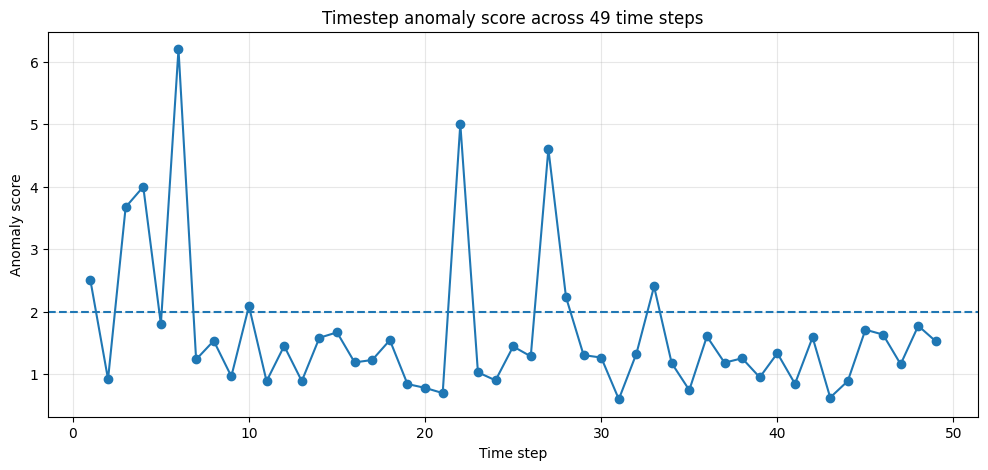

In [35]:
# line plot of timestep anomaly score
plt.figure(figsize=(12, 5))
plt.plot(timestep_eval_df[TIME_COL], timestep_eval_df["timestep_anomaly_score"], marker="o")
plt.axhline(ZSCORE_THRESHOLD, linestyle="--")
plt.title("Timestep anomaly score across 49 time steps")
plt.xlabel("Time step")
plt.ylabel("Anomaly score")
plt.grid(True, alpha=0.3)
plt.show()

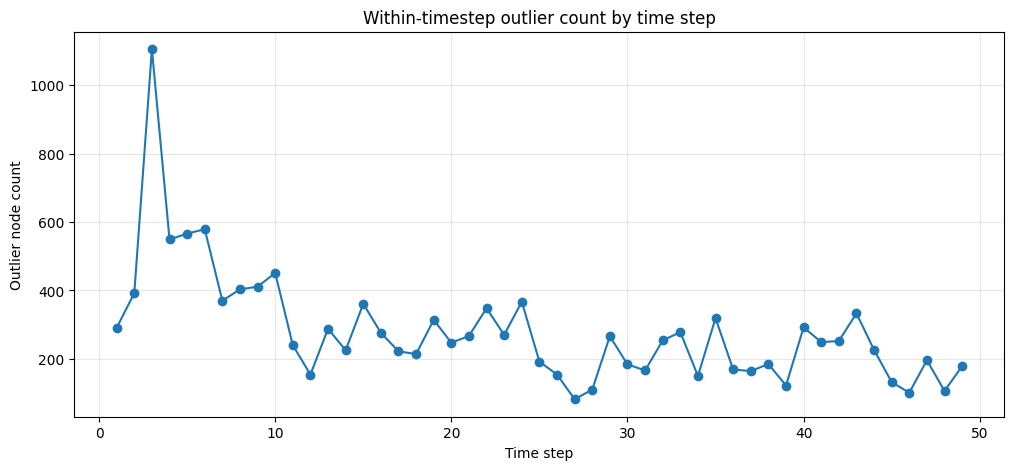

In [36]:
# outlier count by time step
plt.figure(figsize=(12, 5))
plt.plot(timestep_agg_df[TIME_COL], timestep_agg_df["outlier_node_count_t"], marker="o")
plt.title("Within-timestep outlier count by time step")
plt.xlabel("Time step")
plt.ylabel("Outlier node count")
plt.grid(True, alpha=0.3)
plt.show()